
Running Re = 1000
nu = 1.000000e-03
dt = 1.000000e-03
Iter     1 Residual = 3.499e-04
Iter   200 Residual = 4.895e-05
Iter   400 Residual = 3.359e-05
Iter   600 Residual = 2.677e-05
Iter   800 Residual = 2.305e-05
Iter  1000 Residual = 2.253e-05
Iter  1200 Residual = 2.216e-05
Iter  1400 Residual = 2.166e-05
Iter  1600 Residual = 2.119e-05
Iter  1800 Residual = 2.058e-05
Iter  2000 Residual = 1.947e-05
Iter  2200 Residual = 1.790e-05
Iter  2400 Residual = 1.610e-05
Iter  2600 Residual = 1.429e-05
Iter  2800 Residual = 1.258e-05
Iter  3000 Residual = 1.102e-05
Iter  3200 Residual = 9.634e-06
Iter  3400 Residual = 8.420e-06
Iter  3600 Residual = 7.366e-06
Iter  3800 Residual = 6.453e-06
Iter  4000 Residual = 5.663e-06
Iter  4200 Residual = 4.979e-06
Iter  4400 Residual = 4.385e-06
Iter  4600 Residual = 3.869e-06
Iter  4800 Residual = 3.419e-06
Iter  5000 Residual = 3.026e-06

Running Re = 3000
nu = 3.333333e-04
dt = 1.000000e-03
Iter     1 Residual = 1.166e-04
Iter   200 Residual = 2.96

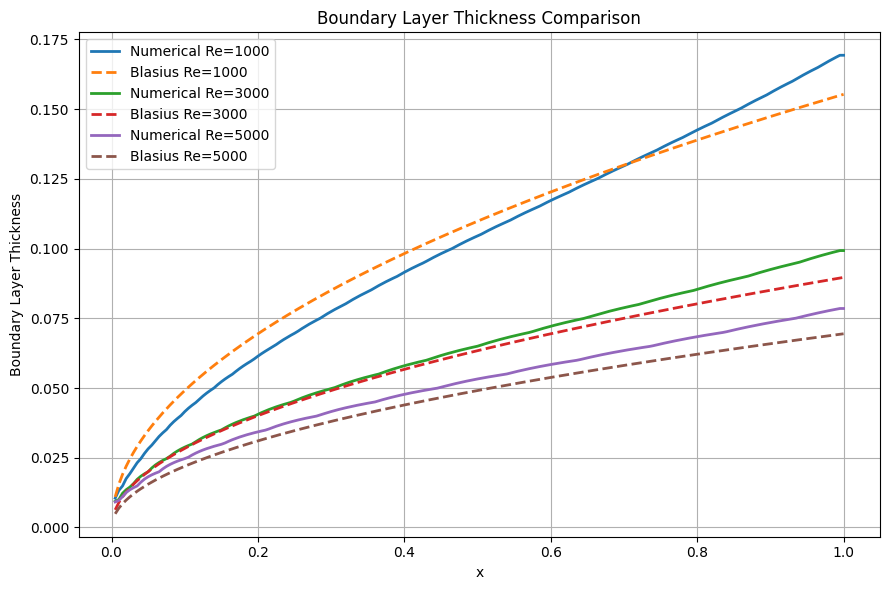

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# FLAT PLATE BOUNDARY LAYER
# STABLE IMPROVED VERSION
# ======================================================

# ======================================================
# DOMAIN
# ======================================================
Lx = 1.0
Ly = 1.0

nx = 201
ny = 201

dx = Lx / (nx - 1)
dy = Ly / (ny - 1)

x = np.linspace(0.0, Lx, nx)
y = np.linspace(0.0, Ly, ny)

X, Y = np.meshgrid(x, y)

# ======================================================
# FLOW PARAMETERS
# ======================================================
U_inf = 1.0

Re_values = [1000, 3000, 5000]

# ======================================================
# STORAGE
# ======================================================
all_delta = []
all_blasius = []
all_x = []

# ======================================================
# LOOP OVER RE
# ======================================================
for Re_L in Re_values:

    print("\n" + "="*60)
    print(f"Running Re = {Re_L}")
    print("="*60)

    nu = U_inf * Lx / Re_L

    # --------------------------------------------------
    # SMALLER DT FOR STABILITY
    # --------------------------------------------------
    dt_conv = 0.2 * dx / U_inf

    dt_diff = 0.1 * dy**2 / nu

    dt = min(dt_conv, dt_diff)

    print(f"nu = {nu:.6e}")
    print(f"dt = {dt:.6e}")

    # --------------------------------------------------
    # SOLVER PARAMETERS
    # --------------------------------------------------
    max_iter = 5000

    poisson_iter = 80

    tol = 1e-6

    # ==================================================
    # INITIALIZE
    # ==================================================
    psi = U_inf * Y.copy()

    omega = np.zeros((ny, nx))

    # ==================================================
    # PSI BC
    # ==================================================
    def apply_psi_bc(psi):

        # wall
        psi[0,:] = 0.0

        # top boundary
        psi[-1,:] = psi[-2,:] + U_inf*dy

        # inlet
        psi[:,0] = U_inf * y

        # outlet
        psi[:,-1] = 2*psi[:,-2] - psi[:,-3]

        return psi

    # ==================================================
    # VELOCITY
    # ==================================================
    def recover_velocity(psi):

        u = np.zeros_like(psi)
        v = np.zeros_like(psi)

        u[1:-1,1:-1] = (
            psi[2:,1:-1] - psi[:-2,1:-1]
        ) / (2*dy)

        v[1:-1,1:-1] = -(
            psi[1:-1,2:] - psi[1:-1,:-2]
        ) / (2*dx)

        # BC
        u[0,:] = 0.0
        v[0,:] = 0.0

        u[-1,:] = U_inf
        v[-1,:] = 0.0

        u[:,0] = U_inf
        v[:,0] = 0.0

        u[:,-1] = u[:,-2]
        v[:,-1] = v[:,-2]

        return u, v

    # ==================================================
    # OMEGA BC
    # ==================================================
    def apply_omega_bc(omega, psi):

        omega[0,1:-1] = (
            -2.0 * psi[1,1:-1]
            / dy**2
        )

        omega[-1,:] = 0.0

        omega[:,0] = 0.0

        omega[:,-1] = 2*omega[:,-2] - omega[:,-3]

        return omega

    # ==================================================
    # FAST POISSON
    # ==================================================
    def solve_poisson(psi, omega):

        dx2 = dx**2
        dy2 = dy**2

        coeff = 2/dx2 + 2/dy2

        for _ in range(poisson_iter):

            psi[1:-1,1:-1] = (

                (psi[1:-1,2:] + psi[1:-1,:-2]) / dx2

                + (psi[2:,1:-1] + psi[:-2,1:-1]) / dy2

                + omega[1:-1,1:-1]

            ) / coeff

            psi = apply_psi_bc(psi)

        return psi

    # ==================================================
    # INITIAL BC
    # ==================================================
    psi = apply_psi_bc(psi)

    omega = apply_omega_bc(omega, psi)

    residual_history = []

    # ==================================================
    # MAIN LOOP
    # ==================================================
    for it in range(1, max_iter+1):

        psi_old = psi.copy()

        u, v = recover_velocity(psi)

        omega = apply_omega_bc(omega, psi)

        omega_c = omega[1:-1,1:-1]

        u_c = u[1:-1,1:-1]

        v_c = v[1:-1,1:-1]

        # --------------------------------------------------
        # CENTRAL DIFFERENCE
        # --------------------------------------------------
        domega_dx_c = (
            omega[1:-1,2:] - omega[1:-1,:-2]
        ) / (2*dx)

        domega_dy_c = (
            omega[2:,1:-1] - omega[:-2,1:-1]
        ) / (2*dy)

        # --------------------------------------------------
        # UPWIND
        # --------------------------------------------------
        domega_dx_u = np.where(
            u_c >= 0.0,

            (omega[1:-1,1:-1] - omega[1:-1,:-2]) / dx,

            (omega[1:-1,2:] - omega[1:-1,1:-1]) / dx
        )

        domega_dy_u = np.where(
            v_c >= 0.0,

            (omega[1:-1,1:-1] - omega[:-2,1:-1]) / dy,

            (omega[2:,1:-1] - omega[1:-1,1:-1]) / dy
        )

        # --------------------------------------------------
        # HYBRID SCHEME
        # --------------------------------------------------
        alpha = 0.85

        domega_dx = (
            alpha*domega_dx_c
            +
            (1-alpha)*domega_dx_u
        )

        domega_dy = (
            alpha*domega_dy_c
            +
            (1-alpha)*domega_dy_u
        )

        # --------------------------------------------------
        # DIFFUSION
        # --------------------------------------------------
        d2omega_dx2 = (
            omega[1:-1,2:]
            - 2*omega_c
            + omega[1:-1,:-2]
        ) / dx**2

        d2omega_dy2 = (
            omega[2:,1:-1]
            - 2*omega_c
            + omega[:-2,1:-1]
        ) / dy**2

        # --------------------------------------------------
        # UPDATE
        # --------------------------------------------------
        omega_new = omega.copy()

        omega_new[1:-1,1:-1] = (

            omega_c

            + dt * (

                -u_c*domega_dx

                -v_c*domega_dy

                + nu*(
                    d2omega_dx2
                    + d2omega_dy2
                )

            )
        )

        # --------------------------------------------------
        # CLIPPING FOR STABILITY
        # --------------------------------------------------
        omega_new = np.clip(
            omega_new,
            -1e6,
            1e6
        )

        omega = omega_new

        omega = apply_omega_bc(omega, psi)

        # --------------------------------------------------
        # POISSON
        # --------------------------------------------------
        psi = solve_poisson(psi, omega)

        # --------------------------------------------------
        # RESIDUAL
        # --------------------------------------------------
        residual = np.max(np.abs(psi - psi_old))

        residual_history.append(residual)

        if it % 200 == 0 or it == 1:

            print(
                f"Iter {it:5d} Residual = {residual:.3e}"
            )

        if residual < tol and it > 300:

            print(f"Converged in {it}")

            break

    # ==================================================
    # FINAL VELOCITY
    # ==================================================
    u, v = recover_velocity(psi)

    # ==================================================
    # DELTA99
    # ==================================================
    delta_99 = np.full(nx, np.nan)

    for i in range(1, nx):

        u_profile = u[:,i] / U_inf

        for j in range(1, ny):

            if (
                u_profile[j-1] < 0.99
                and
                u_profile[j] >= 0.99
            ):

                y1 = y[j-1]
                y2 = y[j]

                u1 = u_profile[j-1]
                u2 = u_profile[j]

                delta_99[i] = y1 + (
                    (0.99-u1)
                    *
                    (y2-y1)
                    /
                    (u2-u1)
                )

                break

    # ==================================================
    # BLASIUS
    # ==================================================
    Re_x = U_inf * x[1:] / nu

    delta_blasius = (
        4.91 * x[1:]
        / np.sqrt(Re_x)
    )

    all_delta.append(delta_99.copy())

    all_blasius.append(delta_blasius.copy())

    all_x.append(x.copy())

# ======================================================
# FINAL PLOT
# ======================================================
plt.figure(figsize=(9,6))

for k, Re_L in enumerate(Re_values):

    plt.plot(
        all_x[k][1:],
        all_delta[k][1:],
        linewidth=2,
        label=f"Numerical Re={Re_L}"
    )

    plt.plot(
        all_x[k][1:],
        all_blasius[k],
        "--",
        linewidth=2,
        label=f"Blasius Re={Re_L}"
    )

plt.xlabel("x")

plt.ylabel("Boundary Layer Thickness")

plt.title("Boundary Layer Thickness Comparison")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()